# Sweet Spot Holiday Index (PCA-Based)

In this notebook I builds a holiday index directly from PCA scores in `Combined_Holiday_PCA_Scores.csv`.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Path to PCA scores (used to build the final PCA-based holiday index)
pca_path = "../Combining_Code_And_Results/Combined_Holiday_PCA_Scores.csv"
# Path to the full combined dataset (used later to build proxy desirability scores)
base_path = "../Combining_Code_And_Results/Combined_Holiday.csv"

pca_df = pd.read_csv(pca_path)
pc_cols = [c for c in pca_df.columns if c.startswith("PC")]

# Quick sanity check so we know the data loaded correctly
print(f"Rows: {len(pca_df)}, PCA columns: {len(pc_cols)}")
display(pca_df.head())

Rows: 170, PCA columns: 9


,country,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,Afghanistan,-1.673589,-0.314019,-0.921635,0.272120,0.249203,0.135223,-0.140204,-0.673531,0.302786
1,Albania,-0.335491,0.365582,-1.290936,-0.047750,-0.779015,0.011714,-0.087705,0.154080,-0.132071
2,Algeria,-1.070279,0.282260,-0.817026,-0.257528,0.126537,-0.555302,0.142725,-0.422682,0.164872
3,Andorra,1.548850,-0.985092,-1.292441,0.068494,-0.396890,0.723031,-0.342639,-0.494043,-0.361665
4,Angola,-0.848082,0.680703,0.952293,1.506613,0.730789,0.929818,-0.388652,0.958470,1.277927


In [12]:
# 1) Estimate each PC importance from its variance in the score table
# Higher variance usually means that component captures more structure in the data
pc_variance = pca_df[pc_cols].var(ddof=0)
pc_weight_all = pc_variance / pc_variance.sum()

# Keep leading PCs until cumulative contribution reaches ~90%
# Reason: this keeps most information while avoiding very small/noisy trailing components 
# originaly I cut off all data after PCA6 , which captured 83% but im going to set it to 90% to try 
# capture as mu
cum = pc_weight_all.cumsum()
selected_pcs = cum[cum <= 0.90].index.tolist()
if not selected_pcs:
    selected_pcs = [pc_cols[0]]

# Include one extra PC just past the threshold for stability
if selected_pcs[-1] != pc_cols[min(len(selected_pcs), len(pc_cols) - 1)]:
    next_idx = len(selected_pcs)
    if next_idx < len(pc_cols):
        selected_pcs.append(pc_cols[next_idx])

# Re-normalize weights so selected PCs sum to 1
weights = pc_weight_all[selected_pcs]
weights = weights / weights.sum()

weight_table = pd.DataFrame({"weight": weights, "cum_weight_all": pc_weight_all[selected_pcs].cumsum()})
display(weight_table)
print(f"Using {len(selected_pcs)} PCs: {selected_pcs}")

,weight,cum_weight_all
PC1,0.302669,0.278713
PC2,0.208033,0.470280
PC3,0.143841,0.602737
PC4,0.111259,0.705190
PC5,0.087592,0.785849
PC6,0.077412,0.857134
PC7,0.069194,0.920851


Using 7 PCs: ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7']


In [13]:
# 2) Build a proxy desirability score from human-friendly rules
# This proxy helps us determine whether each PC direction aligns with "better holiday"
def target_score(series, ideal_low, ideal_high, worst_low, worst_high):
    # Best score near the center of an ideal range, fading toward worst bounds
    s = pd.to_numeric(series, errors="coerce")
    center = (ideal_low + ideal_high) / 2
    left_span = max(center - worst_low, 1e-9)
    right_span = max(worst_high - center, 1e-9)

    score = pd.Series(0.0, index=s.index, dtype=float)
    left_mask = s <= center
    right_mask = s > center
    score[left_mask] = 1 - ((center - s[left_mask]) / left_span)
    score[right_mask] = 1 - ((s[right_mask] - center) / right_span)
    score[s.isna()] = 0.0
    return score.clip(0.0, 1.0)


def low_is_better_score(series, best, worst):
    # Lower values are better (for example: disaster count)
    s = pd.to_numeric(series, errors="coerce")
    span = max(worst - best, 1e-9)
    score = 1 - ((s - best) / span)
    score[s.isna()] = 0.0
    return score.clip(0.0, 1.0)


def high_is_better_score(series, worst, best):
    # Higher values are better (for example: condition score)
    s = pd.to_numeric(series, errors="coerce")
    span = max(best - worst, 1e-9)
    score = (s - worst) / span
    score[s.isna()] = 0.0
    return score.clip(0.0, 1.0)


specs = {
    "temperature_celsius": {"type": "target", "ideal_low": 23.0, "ideal_high": 26.0, "worst_low": 8.0, "worst_high": 38.0},
    "wind_kph": {"type": "target", "ideal_low": 7.0, "ideal_high": 14.0, "worst_low": 0.0, "worst_high": 40.0},
    "uv_index": {"type": "target", "ideal_low": 4.0, "ideal_high": 5.5, "worst_low": 0.0, "worst_high": 11.0},
    "condition_score": {"type": "high", "worst": 0.0, "best": 5.0},
    "Mid_range_meal_pp": {"type": "target", "ideal_low": 8.0, "ideal_high": 28.0, "worst_low": 1.0, "worst_high": 120.0},
    "One_way_local_transport_ticket": {"type": "target", "ideal_low": 0.40, "ideal_high": 1.80, "worst_low": 0.00, "worst_high": 7.0},
    "Apartment": {"type": "target", "ideal_low": 250.0, "ideal_high": 900.0, "worst_low": 80.0, "worst_high": 5500.0},
    "Disaster_Count": {"type": "low", "best": 0.0, "worst": 15.0},
    "Median_Severity": {"type": "low", "best": 0.0, "worst": 1.0},
    "Unique_Days_Under_Threat": {"type": "low", "best": 0.0, "worst": 365.0},
}

# Read base feature table and only score fields that actually exist
proxy_df = pd.read_csv(base_path)
available = [c for c in specs if c in proxy_df.columns]

for col in available:
    cfg = specs[col]
    if cfg["type"] == "target":
        proxy_df[f"score_{col}"] = target_score(proxy_df[col], cfg["ideal_low"], cfg["ideal_high"], cfg["worst_low"], cfg["worst_high"])
    elif cfg["type"] == "low":
        proxy_df[f"score_{col}"] = low_is_better_score(proxy_df[col], cfg["best"], cfg["worst"])
    else:
        proxy_df[f"score_{col}"] = high_is_better_score(proxy_df[col], cfg["worst"], cfg["best"])

def geometric_mean_of_existing(frame, cols, eps=1e-6):
    # Geometric mean rewards balanced performance across metrics
    use_cols = [c for c in cols if c in frame.columns]
    if not use_cols:
        return pd.Series(0.0, index=frame.index)
    clipped = frame[use_cols].clip(lower=eps)
    return np.exp(np.log(clipped).mean(axis=1))

# Build grouped proxy scores, then a single weighted proxy holiday index
proxy_df["Economy_Score"] = geometric_mean_of_existing(proxy_df, ["score_Mid_range_meal_pp", "score_One_way_local_transport_ticket", "score_Apartment"])
proxy_df["Environment_Score"] = geometric_mean_of_existing(proxy_df, ["score_temperature_celsius", "score_wind_kph", "score_uv_index", "score_condition_score"])
proxy_df["Risk_Score"] = geometric_mean_of_existing(proxy_df, ["score_Disaster_Count", "score_Median_Severity", "score_Unique_Days_Under_Threat"])
proxy_df["Proxy_Holiday_Index"] = 0.35 * proxy_df["Economy_Score"] + 0.40 * proxy_df["Environment_Score"] + 0.25 * proxy_df["Risk_Score"]

proxy_view = proxy_df[["country", "Proxy_Holiday_Index"]].copy()
display(proxy_view.head())

,country,Proxy_Holiday_Index
0,Afghanistan,0.521976
1,Albania,0.740208
2,Algeria,0.602607
3,Andorra,0.784213
4,Angola,0.498491


In [14]:
# 3) Orient PCs with proxy correlation, then build final PCA-based index
# Reason: PCA directions are arbitrary (+/-), so we align each PC to "higher is better"
work = pca_df.merge(proxy_view, on="country", how="left")

pc_sign = {}
for pc in selected_pcs:
    r = work[[pc, "Proxy_Holiday_Index"]].corr().iloc[0, 1]
    if pd.isna(r) or r == 0:
        # If correlation is undefined/flat, keep original direction
        pc_sign[pc] = 1.0
    else:
        pc_sign[pc] = 1.0 if r > 0 else -1.0

# Apply orientation sign to each selected component
for pc in selected_pcs:
    work[f"oriented_{pc}"] = work[pc] * pc_sign[pc]

# Weighted sum of oriented PCs gives the raw PCA holiday score
work["Holiday_Index_PCA_raw"] = sum(work[f"oriented_{pc}"] * weights[pc] for pc in selected_pcs)

# Min-max scale to [0, 1] so results are easy to interpret and compare
lo, hi = work["Holiday_Index_PCA_raw"].min(), work["Holiday_Index_PCA_raw"].max()
span = max(hi - lo, 1e-9)
work["Holiday_Index_PCA"] = (work["Holiday_Index_PCA_raw"] - lo) / span

sign_table = pd.DataFrame({
    "pc": selected_pcs,
    "sign": [pc_sign[p] for p in selected_pcs],
    "weight": [weights[p] for p in selected_pcs]
})
display(sign_table)
display(work[["country", "Holiday_Index_PCA"]].head())

,pc,sign,weight
0,PC1,1.0,0.302669
1,PC2,1.0,0.208033
2,PC3,-1.0,0.143841
3,PC4,-1.0,0.111259
4,PC5,-1.0,0.087592
5,PC6,1.0,0.077412
6,PC7,1.0,0.069194


,country,Holiday_Index_PCA
0,Afghanistan,0.543660
1,Albania,0.769608
2,Algeria,0.646513
3,Andorra,0.857755
4,Angola,0.560006


,country,Holiday_Index_PCA,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,Liechtenstein,1.000000,3.884958,-2.026709,0.360437,-0.031404,-0.523577,2.128177,0.657090
1,Denmark,0.999003,3.541732,-0.864179,0.513044,-1.197241,0.807104,0.816080,0.212494
2,Norway,0.985350,3.531827,-1.537413,-0.014947,-0.842462,0.439317,1.345515,0.066788
3,Netherlands,0.975250,3.050522,-0.709932,0.115013,-0.690311,0.452351,0.812197,0.347628
4,Finland,0.971585,3.069693,-0.952049,-0.042940,-1.193759,0.783587,0.868350,0.041691
5,United Kingdom,0.963122,2.869096,-0.909299,-0.154957,-0.519918,0.255545,1.003826,0.431920
6,Switzerland,0.947842,3.704546,-2.051588,0.755378,0.113947,-0.917655,1.535000,0.341131
7,Monaco,0.945278,6.392362,-1.293942,4.129537,2.983249,-3.003535,-1.271149,-1.684948
8,Ireland,0.939591,3.119524,-1.009830,0.180219,-0.627226,0.337666,0.357635,-0.092623
9,Israel,0.926603,1.872258,0.959285,0.894479,-0.332812,-0.558738,0.274434,-0.237920


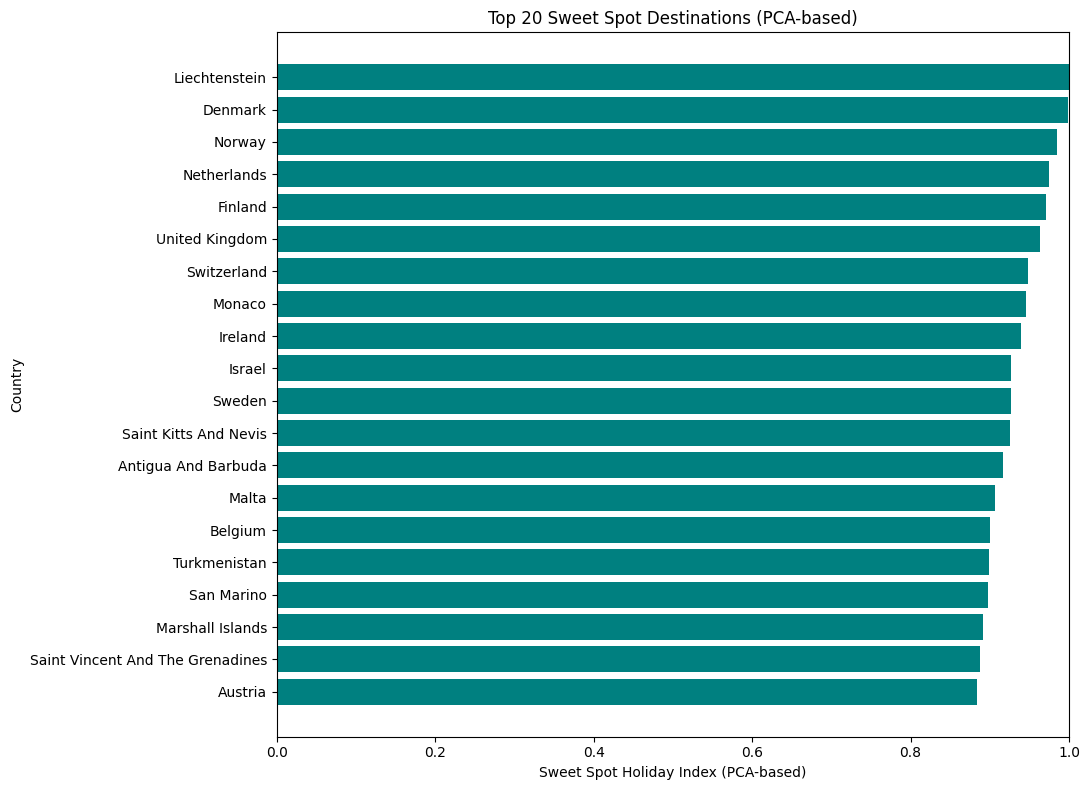

Saved PCA index output to: ../Combining_Code_And_Results/Combined_Holiday_PCA_Index_Results.csv


In [15]:
# 4) Rank countries and visualize the top 20 by PCA index
top_20_pca = (
    work.sort_values("Holiday_Index_PCA", ascending=False)
        .loc[:, ["country", "Holiday_Index_PCA"] + selected_pcs]
        .head(20)
        .reset_index(drop=True)
)

display(top_20_pca)

# Horizontal bar chart makes country labels easier to read
plot_df = top_20_pca.sort_values("Holiday_Index_PCA", ascending=True)
plt.figure(figsize=(11, 8))
plt.barh(plot_df["country"], plot_df["Holiday_Index_PCA"], color="teal")
plt.xlabel("Sweet Spot Holiday Index (PCA-based)")
plt.ylabel("Country")
plt.title("Top 20 Sweet Spot Destinations (PCA-based)")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Save full country-level PCA index output for reuse in reports/analysis
output_path = "../Combining_Code_And_Results/Combined_Holiday_PCA_Index_Results.csv"
work[["country", "Holiday_Index_PCA"] + selected_pcs].to_csv(output_path, index=False)
print(f"Saved PCA index output to: {output_path}")